In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.black_scholes import BlackScholes
from src.engine.monte_carlo import generate_gbm_paths, price_american_mc

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
S0 = 100
K = 100
T = 1.0
r = 0.05
sigma = 0.20

n_paths = 200000
n_steps = 252
dt = T / n_steps


print(f"Parameters: S0={S0}, K={K}, T={T}, r={r}, sigma={sigma}")
print(f"MC settings: {n_paths} paths, {n_steps} steps")

Parameters: S0=100, K=100, T=1.0, r=0.05, sigma=0.2
MC settings: 200000 paths, 252 steps


In [3]:
paths = generate_gbm_paths(S0, r, sigma, T, n_steps, n_paths, seed=42)

american_put = price_american_mc(paths, K, r, dt, 'put')
european_put = BlackScholes(S0, K, T, r, sigma).price('put')

print(f"American put (LSM): {american_put:.4f}")
print(f"European put: {european_put:.4f}")
print(f"Early exercise premium: {american_put - european_put:.4f}")

American put (LSM): 6.0596
European put: 5.5735
Early exercise premium: 0.4861


In [4]:
# Call américain sans dividende
# Théorie : un call américain sur une action sans dividende ne s'exerce jamais avant maturité
# Donc son prix est égal à celui du call européen.

european_call = BlackScholes(S0, K, T, r, sigma).price('call')
american_call = european_call

print(f"European call (Black-Scholes): {european_call:.4f}")
print(f"American call (theoretical): {american_call:.4f}")
print()
print("Note: For a non-dividend-paying stock, early exercise of an American call is never optimal.")
print("The American call price therefore equals the European call price by no-arbitrage.")

European call (Black-Scholes): 10.4506
American call (theoretical): 10.4506

Note: For a non-dividend-paying stock, early exercise of an American call is never optimal.
The American call price therefore equals the European call price by no-arbitrage.


In [5]:
# Vérification numérique : le prix LSM doit converger vers la valeur théorique
american_call_mc = price_american_mc(paths, K, r, dt, 'call')
print(f"American call (LSM, {n_paths} paths): {american_call_mc:.4f}")
print(f"Difference from theoretical: {abs(american_call_mc - european_call):.4f}")
print("(The difference is due to Monte Carlo noise and regression bias.)")

American call (LSM, 200000 paths): 10.5047
Difference from theoretical: 0.0541
(The difference is due to Monte Carlo noise and regression bias.)


Computing exercise boundary...


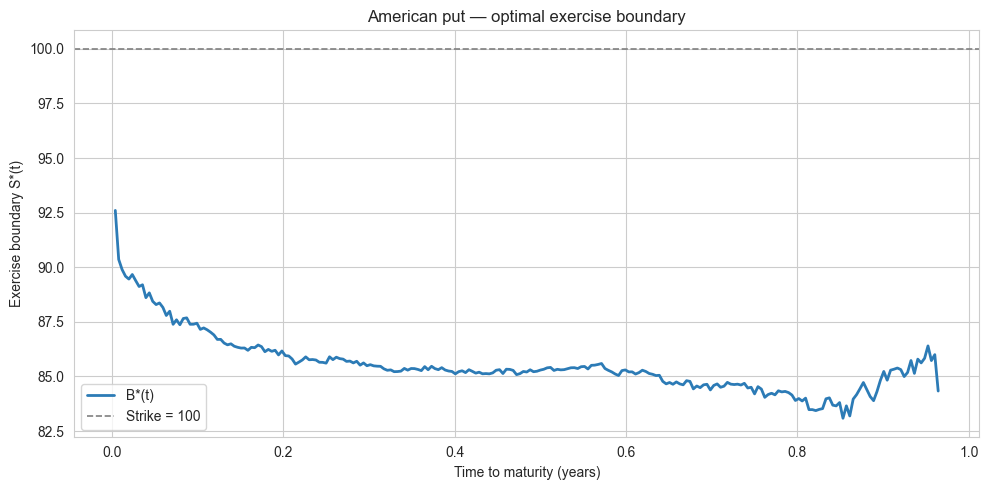

In [6]:
def exercise_boundary(S_paths, K, r, dt, option_type="put"):
    n_paths, n_steps_plus1 = S_paths.shape
    n_steps = n_steps_plus1 - 1
    T_total = n_steps * dt

    payoffs = np.maximum(K - S_paths, 0) if option_type == "put" else np.maximum(S_paths - K, 0)

    # same corrected LS: cashflows discounted to t=0
    cashflow = np.exp(-r * T_total) * payoffs[:, -1].copy()
    boundary = []

    for t in range(n_steps - 1, 0, -1):
        itm = payoffs[:, t] > 0
        if itm.sum() < 20:
            continue

        X = S_paths[itm, t]
        Y = cashflow[itm]

        poly = np.polyfit(X, Y, 2)
        continuation = np.polyval(poly, X)

        exercise_val = np.exp(-r * t * dt) * payoffs[itm, t]
        exercise_now = exercise_val > continuation
        cashflow[itm] = np.where(exercise_now, exercise_val, cashflow[itm])

        # B*(t) = max stock price at which early exercise is still optimal
        if exercise_now.sum() > 0:
            boundary_price = S_paths[itm, t][exercise_now].max()
            boundary.append((T_total - t * dt, boundary_price))

    return sorted(boundary)

print("Computing exercise boundary...")
paths_boundary = generate_gbm_paths(S0, r, sigma, T, n_steps, 100000, seed=42)
boundary = exercise_boundary(paths_boundary, K, r, dt)

times, prices = zip(*boundary)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(times, prices, lw=2, color="#2c7bb6", label="B*(t)")
ax.axhline(K, color="gray", ls="--", lw=1.2, label=f"Strike = {K}")
ax.set_xlabel("Time to maturity (years)")
ax.set_ylabel("Exercise boundary S*(t)")
ax.set_title("American put — optimal exercise boundary")
ax.legend()
plt.tight_layout()
plt.show()


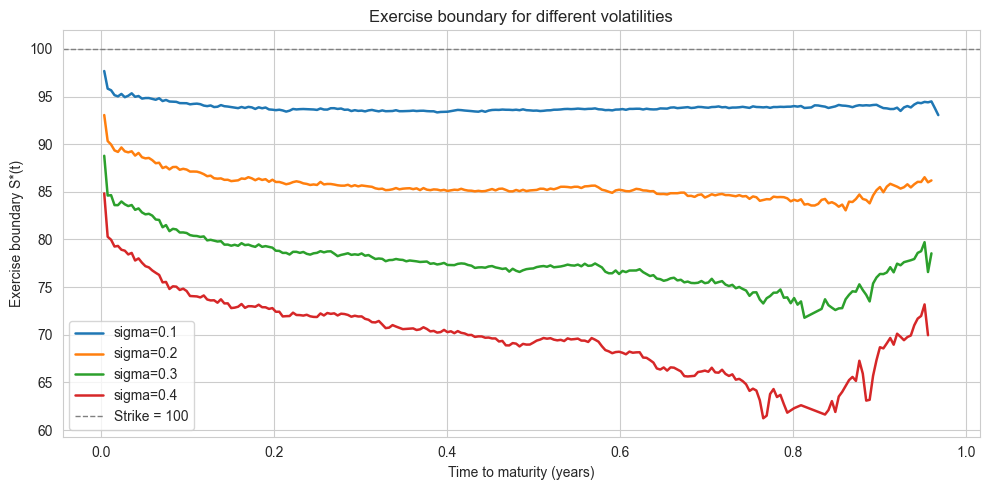

In [7]:
# boundary sensitivity to volatility -- more vol = lower exercise threshold
fig, ax = plt.subplots(figsize=(10, 5))

for sig in [0.10, 0.20, 0.30, 0.40]:
    p = generate_gbm_paths(S0, r, sig, T, n_steps, 80000, seed=42)
    b = exercise_boundary(p, K, r, dt)
    if b:
        t_b, p_b = zip(*b)
        ax.plot(t_b, p_b, lw=1.8, label=f"sigma={sig}")

ax.axhline(K, color="gray", ls="--", lw=1, label=f"Strike = {K}")
ax.set_xlabel("Time to maturity (years)")
ax.set_ylabel("Exercise boundary S*(t)")
ax.set_title("Exercise boundary for different volatilities")
ax.legend()
plt.tight_layout()
plt.show()


In [8]:
times_arr = np.array(times)
prices_arr = np.array(prices)

print(f"Boundary at T=1y (far from maturity): {prices_arr[times_arr > 0.9].mean():.2f}")
print(f"Boundary at T=0  (near maturity):      {prices_arr[times_arr < 0.1].mean():.2f}")
print(f"Expected: boundary rises from ~{prices_arr[times_arr > 0.9].mean():.0f} to ~{K} as we approach maturity")


Boundary at T=1y (far from maturity): 85.42
Boundary at T=0  (near maturity):      88.63
Expected: boundary rises from ~85 to ~100 as we approach maturity


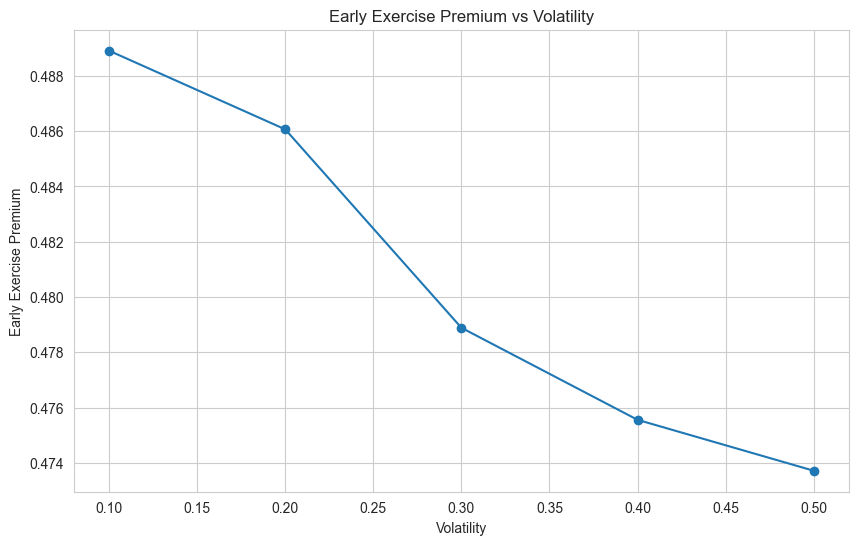

In [9]:
sigmas = [0.1, 0.2, 0.3, 0.4, 0.5]
premiums = []

for sig in sigmas:
    paths_sig = generate_gbm_paths(S0, r, sig, T, n_steps, n_paths, seed=42)
    american = price_american_mc(paths_sig, K, r, dt, 'put')
    european = BlackScholes(S0, K, T, r, sig).price('put')
    premiums.append(american - european)

plt.figure(figsize=(10, 6))
plt.plot(sigmas, premiums, 'o-')
plt.xlabel('Volatility')
plt.ylabel('Early Exercise Premium')
plt.title('Early Exercise Premium vs Volatility')
plt.grid(True)
plt.show()

/Users/alexandreboyer/coding/GitHub/option-pricing-models/notebooks/../src/engine/monte_carlo.py:56: RankWarning: Polyfit may be poorly conditioned
  poly = np.polyfit(X, Y, 2)  # degree 2 should be enough
/Users/alexandreboyer/coding/GitHub/option-pricing-models/notebooks/../src/engine/monte_carlo.py:56: RankWarning: Polyfit may be poorly conditioned
  poly = np.polyfit(X, Y, 2)  # degree 2 should be enough
/Users/alexandreboyer/coding/GitHub/option-pricing-models/notebooks/../src/engine/monte_carlo.py:56: RankWarning: Polyfit may be poorly conditioned
  poly = np.polyfit(X, Y, 2)  # degree 2 should be enough
/Users/alexandreboyer/coding/GitHub/option-pricing-models/notebooks/../src/engine/monte_carlo.py:56: RankWarning: Polyfit may be poorly conditioned
  poly = np.polyfit(X, Y, 2)  # degree 2 should be enough
/Users/alexandreboyer/coding/GitHub/option-pricing-models/notebooks/../src/engine/monte_carlo.py:56: RankWarning: Polyfit may be poorly conditioned
  poly = np.polyfit(X, Y, 2)

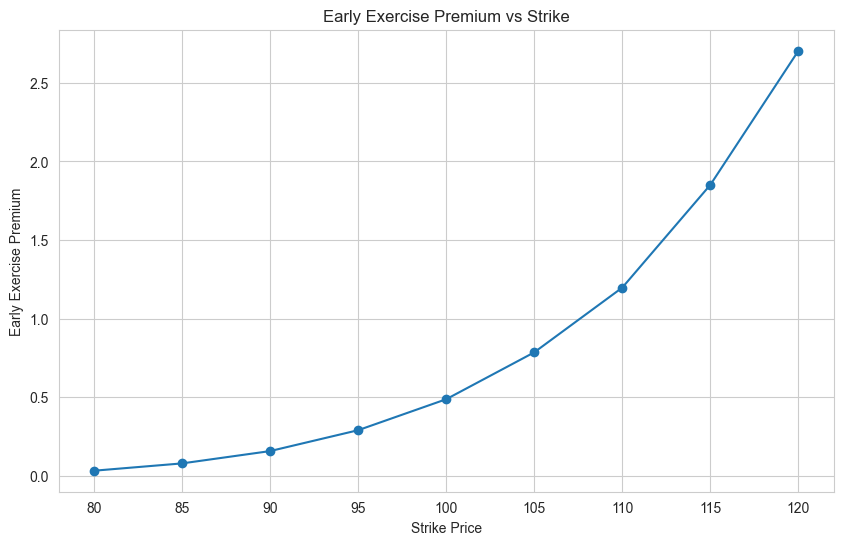

In [10]:
strikes = np.arange(80, 121, 5)
premiums_strike = []

for strike in strikes:
    paths_strike = generate_gbm_paths(S0, r, sigma, T, n_steps, n_paths, seed=42)
    american = price_american_mc(paths_strike, strike, r, dt, 'put')
    european = BlackScholes(S0, strike, T, r, sigma).price('put')
    premiums_strike.append(american - european)

plt.figure(figsize=(10, 6))
plt.plot(strikes, premiums_strike, 'o-')
plt.xlabel('Strike Price')
plt.ylabel('Early Exercise Premium')
plt.title('Early Exercise Premium vs Strike')
plt.grid(True)
plt.show()

In [11]:
print("\nStrike analysis:")
print(f"{'Strike':<8} {'Euro Put':<12} {'US Put':<12} {'Premium':<12} {'Ratio Premium/Price':<20}")
print("-"*65)

for strike, premium in zip(strikes, premiums_strike):
    euro = BlackScholes(S0, strike, T, r, sigma).price('put')
    us = euro + premium
    ratio = premium / euro if euro > 0 else 0
    print(f"{strike:<8} {euro:<12.4f} {us:<12.4f} {premium:<12.4f} {ratio:<20.4f}")


Strike analysis:
Strike   Euro Put     US Put       Premium      Ratio Premium/Price 
-----------------------------------------------------------------
80       0.6872       0.7182       0.0310       0.0451              
85       1.3238       1.4013       0.0776       0.0586              
90       2.3101       2.4661       0.1560       0.0675              
95       3.7133       4.0022       0.2889       0.0778              
100      5.5735       6.0596       0.4861       0.0872              
105      7.9004       8.6850       0.7846       0.0993              
110      10.6753      11.8721      1.1968       0.1121              
115      13.8580      15.7091      1.8512       0.1336              
120      17.3950      20.0999      2.7049       0.1555              


   1000 paths: 6.2118
   5000 paths: 5.9789
  10000 paths: 6.0200
  25000 paths: 6.0124
  50000 paths: 6.0376
 100000 paths: 6.0555


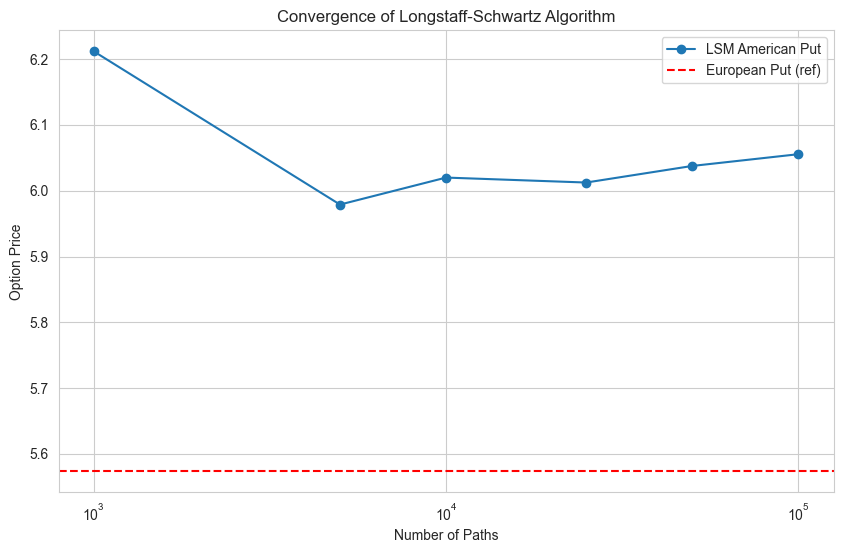

In [12]:
n_paths_list = [1000, 5000, 10000, 25000, 50000, 100000]
american_prices = []
european_ref = BlackScholes(S0, K, T, r, sigma).price('put')

for n in n_paths_list:
    paths_n = generate_gbm_paths(S0, r, sigma, T, n_steps, n, seed=42)
    american = price_american_mc(paths_n, K, r, dt, 'put')
    american_prices.append(american)
    print(f"{n:7d} paths: {american:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(n_paths_list, american_prices, 'o-', label='LSM American Put')
plt.axhline(y=european_ref, color='r', linestyle='--', label='European Put (ref)')
plt.xscale('log')
plt.xlabel('Number of Paths')
plt.ylabel('Option Price')
plt.title('Convergence of Longstaff-Schwartz Algorithm')
plt.legend()
plt.grid(True)
plt.show()